Saving przykladowe_dane_ml.csv to przykladowe_dane_ml (10).csv
Podgląd danych:
         Data  Wartość
0  2024-01-01       99
1  2024-01-02       69
2  2024-01-03       41
3  2024-01-04       46
4  2024-01-05       75

Brakujące wartości w kolumnach:
Data       0
Wartość    0
dtype: int64

Statystyki opisowe:
        Wartość
count  30.00000
mean   59.90000
std    25.67348
min    12.00000
25%    38.00000
50%    64.00000
75%    77.25000
max    99.00000

Macierz korelacji:
                         Wartość  Średnia_krocząca   Różnica  \
Wartość                 1.000000          0.449792  0.756694   
Średnia_krocząca        0.449792          1.000000 -0.030679   
Różnica                 0.756694         -0.030679  1.000000   
Wartość_znormalizowana  1.000000          0.449792  0.756694   

                        Wartość_znormalizowana  
Wartość                               1.000000  
Średnia_krocząca                      0.449792  
Różnica                               0.756694  
Wartość_z

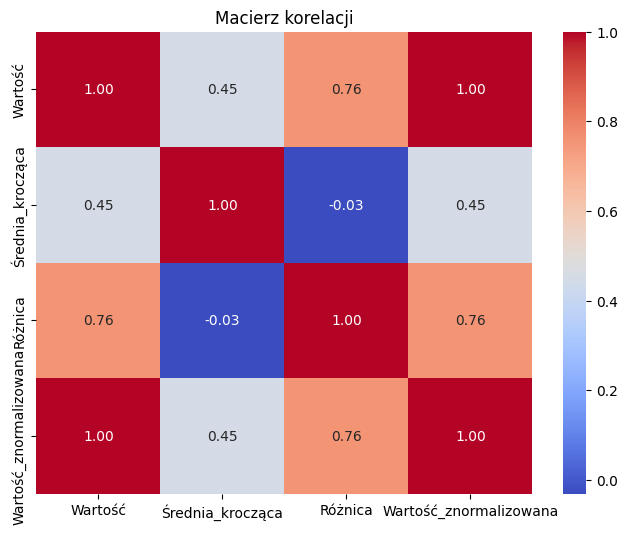


Zestaw treningowy: X_train shape: (22, 3) y_train shape: (22,)
Zestaw testowy: X_test shape: (6, 3) y_test shape: (6,)

Porównanie metryk modeli:
Model regresji liniowej:
MAE: 2.7237471537470508e-14, MSE: 1.1864468014524018e-27, RMSE: 3.444483707977731e-14, R2: 1.0

Model Random Forest:
MAE: 3.801666666666667, MSE: 22.818816666666674, RMSE: 4.776904506756093, R2: 0.9742806073888541


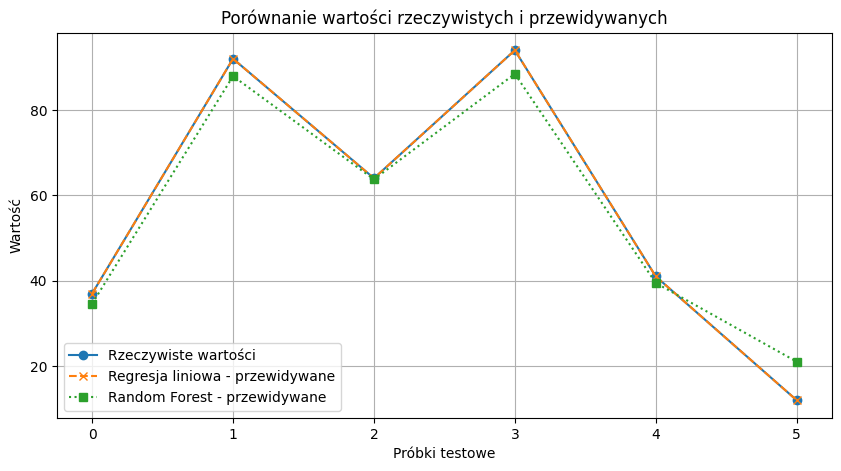

In [13]:
# Importowanie bibliotek
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Wczytanie pliku CSV (możesz przesłać swój plik do Google Colab)
from google.colab import files
uploaded = files.upload()

# Odczytanie pliku CSV do DataFrame
filename = list(uploaded.keys())[0]  # Pobranie nazwy przesłanego pliku
df = pd.read_csv(filename)

# Wyświetlenie pierwszych kilku wierszy danych
print("Podgląd danych:")
print(df.head())

# Sprawdzenie brakujących wartości
total_missing = df.isnull().sum()
print("\nBrakujące wartości w kolumnach:")
print(total_missing)

# Podstawowe statystyki opisowe
descriptive_stats = df.describe()
print("\nStatystyki opisowe:")
print(descriptive_stats)






# Dodanie nowej kolumny - średnia krocząca (rolling mean) z oknem 3
df["Średnia_krocząca"] = df.iloc[:, 1].rolling(window=3).mean()

# Obliczenie różnicy między kolejnymi wartościami (diff)
df["Różnica"] = df.iloc[:, 1].diff()

# Normalizacja wartości (min-max scaling)
scaler = MinMaxScaler()
df["Wartość_znormalizowana"] = scaler.fit_transform(df.iloc[:, 1].values.reshape(-1,1))

# Usunięcie pierwszego wiersza z brakującymi wartościami po różnicy
df = df.dropna()

# Analiza korelacji między zmiennymi
correlation_matrix = df[['Wartość', 'Średnia_krocząca', 'Różnica', 'Wartość_znormalizowana']].corr()
print("\nMacierz korelacji:")
print(correlation_matrix)

# Wizualizacja macierzy korelacji
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji')
plt.show()

# Przygotowanie danych dla uczenia maszynowego
X = df[["Średnia_krocząca", "Różnica", "Wartość_znormalizowana"]]
y = df.iloc[:, 1]  # Cel do przewidywania

# Podział na zestaw treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nZestaw treningowy: X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("Zestaw testowy: X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

# Tworzenie i trenowanie modelu regresji liniowej
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Tworzenie i trenowanie modelu lasu losowego
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Przewidywanie wartości na zbiorze testowym
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Ocena modelu regresji liniowej
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Ocena modelu lasu losowego
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nPorównanie metryk modeli:")
print("Model regresji liniowej:")
print(f"MAE: {mae_lr}, MSE: {mse_lr}, RMSE: {rmse_lr}, R2: {r2_lr}")
print("\nModel Random Forest:")
print(f"MAE: {mae_rf}, MSE: {mse_rf}, RMSE: {rmse_rf}, R2: {r2_rf}")

# Wizualizacja rzeczywistych i przewidywanych wartości dla obu modeli
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Rzeczywiste wartości', marker='o')
plt.plot(y_pred_lr, label='Regresja liniowa - przewidywane', marker='x', linestyle='dashed')
plt.plot(y_pred_rf, label='Random Forest - przewidywane', marker='s', linestyle='dotted')
plt.xlabel('Próbki testowe')
plt.ylabel('Wartość')
plt.title('Porównanie wartości rzeczywistych i przewidywanych')
plt.legend()
plt.grid()
plt.show()


# Nowa sekcja